In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [7]:
# Store file metadata instead of loading all data into memory
file_registry = {
    "small": {"50": {}, "150": {}, "650": {}, "1000": {}},
    "medium": {"50": {}, "150": {}, "650": {}, "1000": {}},
    "big": {"50": {}, "150": {}, "650": {}, "1000": {}}
}

csv_files = glob.glob('simulated/*.csv')
display(f"Found {len(csv_files)} CSV files")

for instance_file in csv_files:
    # Parse filename for metadata without loading the file
    instance_info = instance_file.split(".")[0].split("-")
    instance_type = instance_info[1]
    instance_alg = instance_info[4]
    
    if instance_alg == "A":
        instance_capacity = instance_info[5]
        vams = instance_info[7]
        instance_name = "Algorithm A"
    elif instance_alg == "B":
        instance_capacity = instance_info[5]
        cr = instance_info[6]
        omsms = instance_info[7]
        omsdtp = instance_info[8]
        vams = instance_info[10]
        vadtp = instance_info[11]
        instance_name = "Algorithm B"
    else:
        emsms = instance_info[5]
        emsdtp = instance_info[6]
        instance_capacity = instance_info[7]
        omsms = instance_info[8]
        omsdtp = instance_info[9]
        cr = instance_info[10]
        pams = instance_info[11]
        ocr = instance_info[12]
        dmsms = instance_info[14]
        if pams == "ROUND_ROBIN":
            instance_name = "Algorithm C"
        else:
            continue
    
    # Store only file path and metadata
    file_registry[instance_type][instance_capacity][instance_name] = {
        'filepath': instance_file,
        'instance_type': instance_type,
        'instance_capacity': instance_capacity,
        'instance_name': instance_name
    }
    
    display(f"Registered: {instance_name} - {instance_type} - {instance_capacity}")

display(f"\nFile registry created with {sum(len(file_registry[t][c]) for t in file_registry for c in file_registry[t])} entries")
display("No data loaded into memory yet - files will be read as needed for plotting.")

'Found 40 CSV files'

'Registered: Algorithm A - big - 1000'

'Registered: Algorithm A - big - 150'

'Registered: Algorithm A - big - 50'

'Registered: Algorithm A - big - 650'

...

'Registered: Algorithm C - small - 150'

'Registered: Algorithm C - small - 50'

'Registered: Algorithm C - small - 650'

'\nFile registry created with 36 entries'

'No data loaded into memory yet - files will be read as needed for plotting.'

In [8]:
def load_csv_data(filepath):
    """
    Load CSV file and remove unwanted columns. 
    Always loads the complete file (no sampling).
    """
    columns_to_remove = [
        "id", "server_event", "server_id", "remaining_server_capacity", 
        "server_usage_pct", "server_time_cost", "n_servers_total", 
        "avg_streams_in", "avg_streams_out", "avg_publishers", "avg_viewers"
    ]
    
    # Read the complete CSV
    df = pd.read_csv(filepath)
    
    # Remove unwanted columns if they exist
    columns_to_drop = [col for col in columns_to_remove if col in df.columns]
    if columns_to_drop:
        df = df.drop(columns=columns_to_drop)
    
    return df

def calculate_session_progression(df):
    """
    Calculate session progression from instance_event column.
    Rules:
      - instance_event == 0: start session (increment)
      - instance_event == 2: end session (decrement, never below 0)
    """
    if df is None or len(df) == 0 or "instance_event" not in df.columns:
        return []
    
    sessions = []
    active = 0
    
    for event in df["instance_event"].tolist():
        if event == 0:
            active += 1
        elif event == 2:
            active = max(0, active - 1)
        sessions.append(active)
    
    return sessions

# Algorithm colors for consistent plotting
alg_colors = {"A": "blue", "B": "orange", "C": "green"}
colors_base = ["red", "purple", "brown", "pink", "gray", "olive", "cyan"]
capacities = ["50", "150", "650", "1000"]
instance_types = ["small", "medium", "big"]
algorithms = ["Algorithm A", "Algorithm B", "Algorithm C"]

ValueError: x and y must have same first dimension, but have shapes (381864,) and (0,)

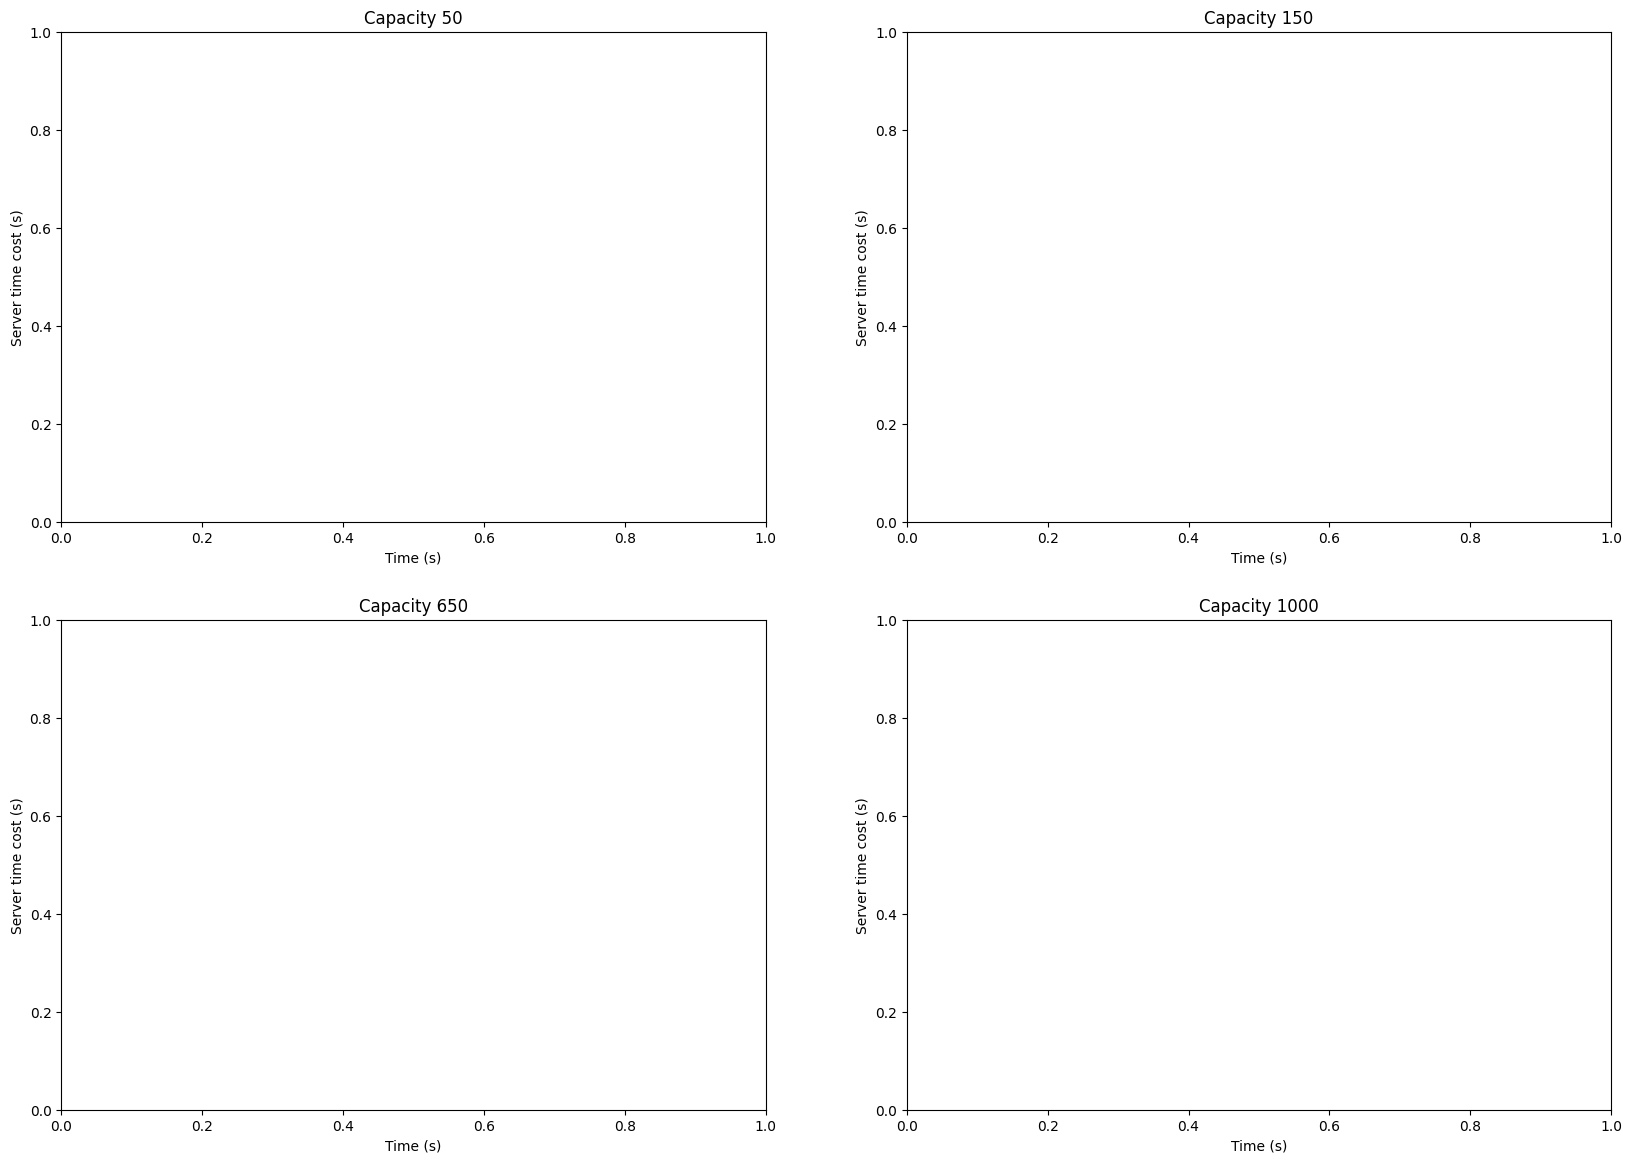

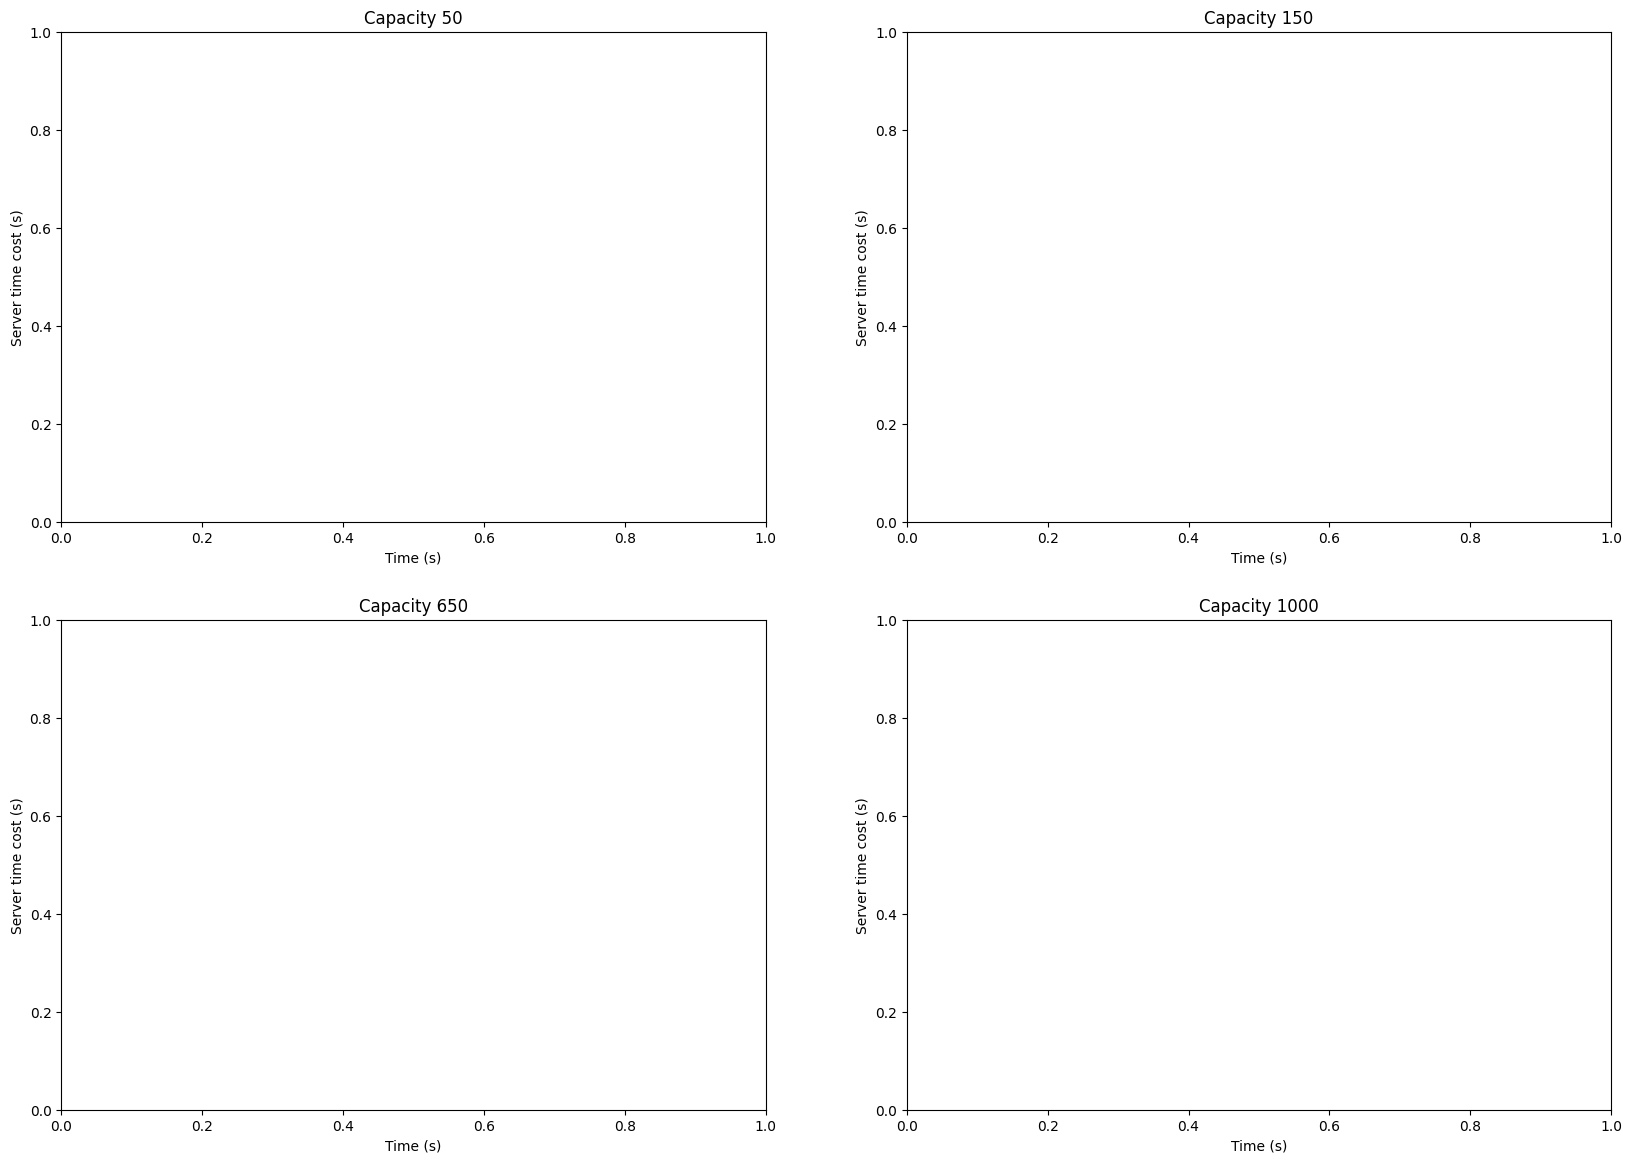

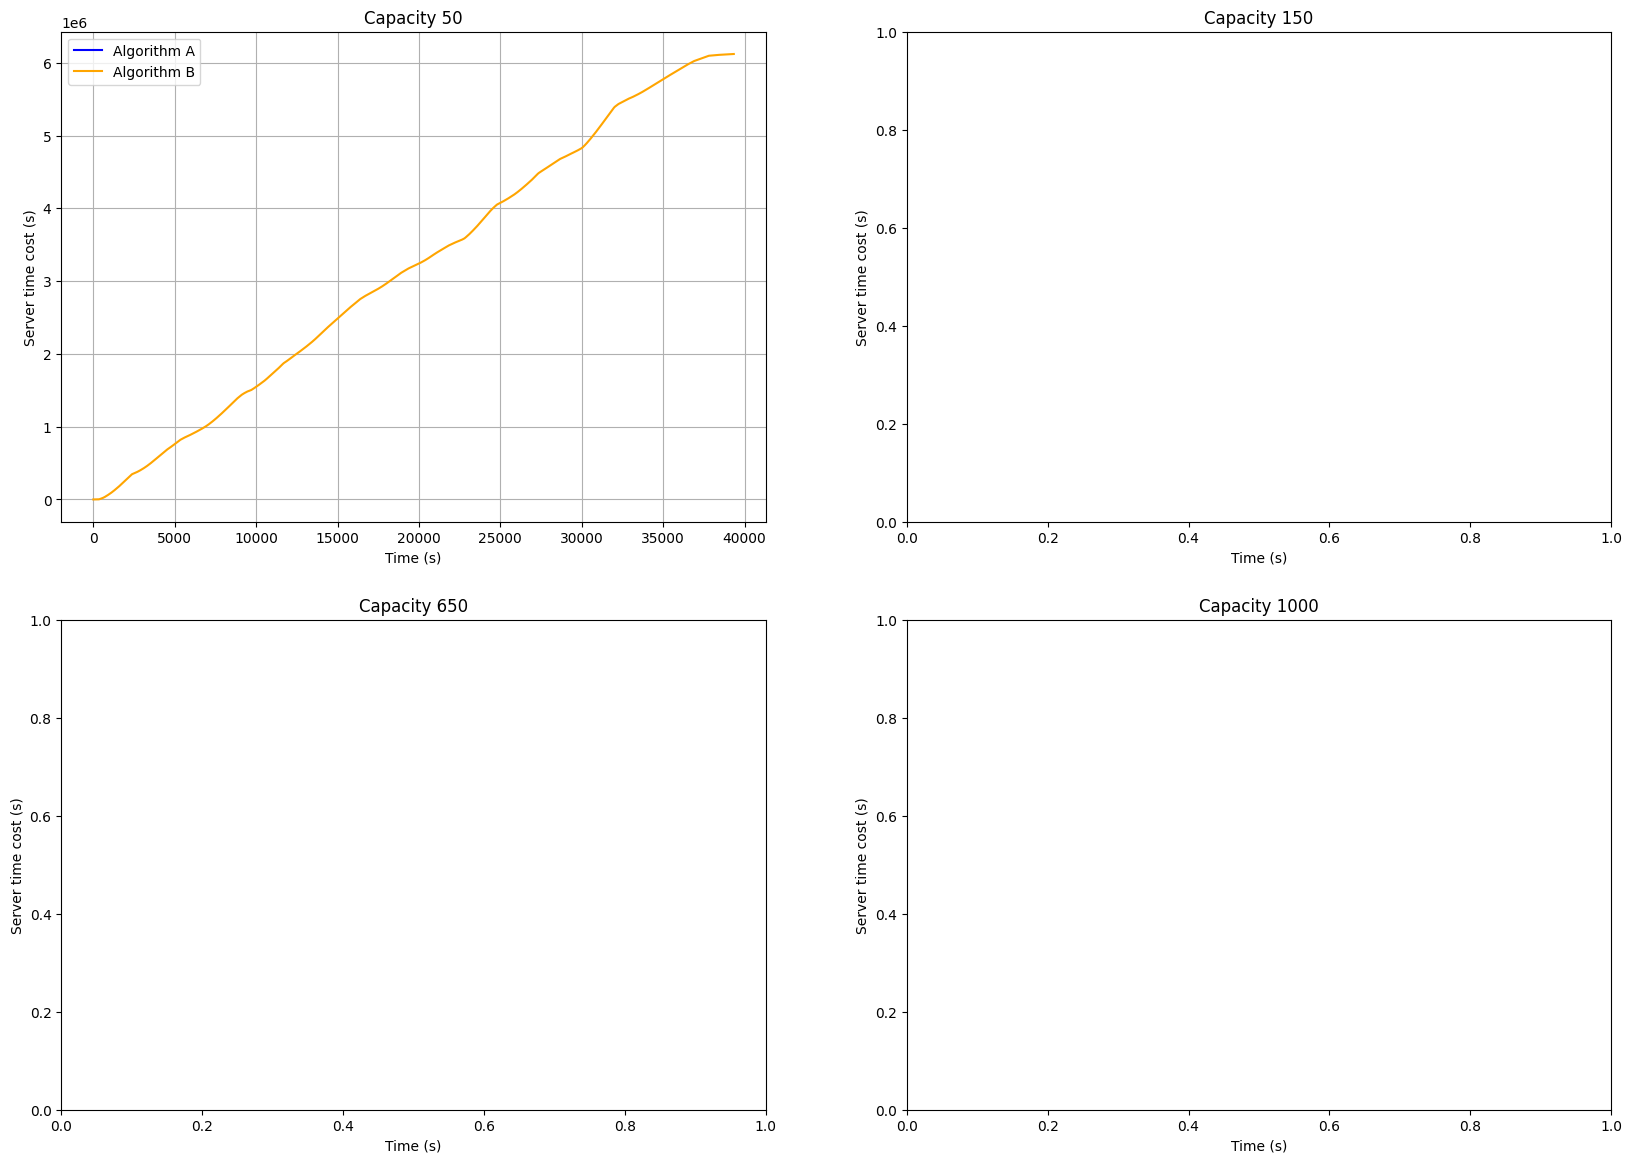

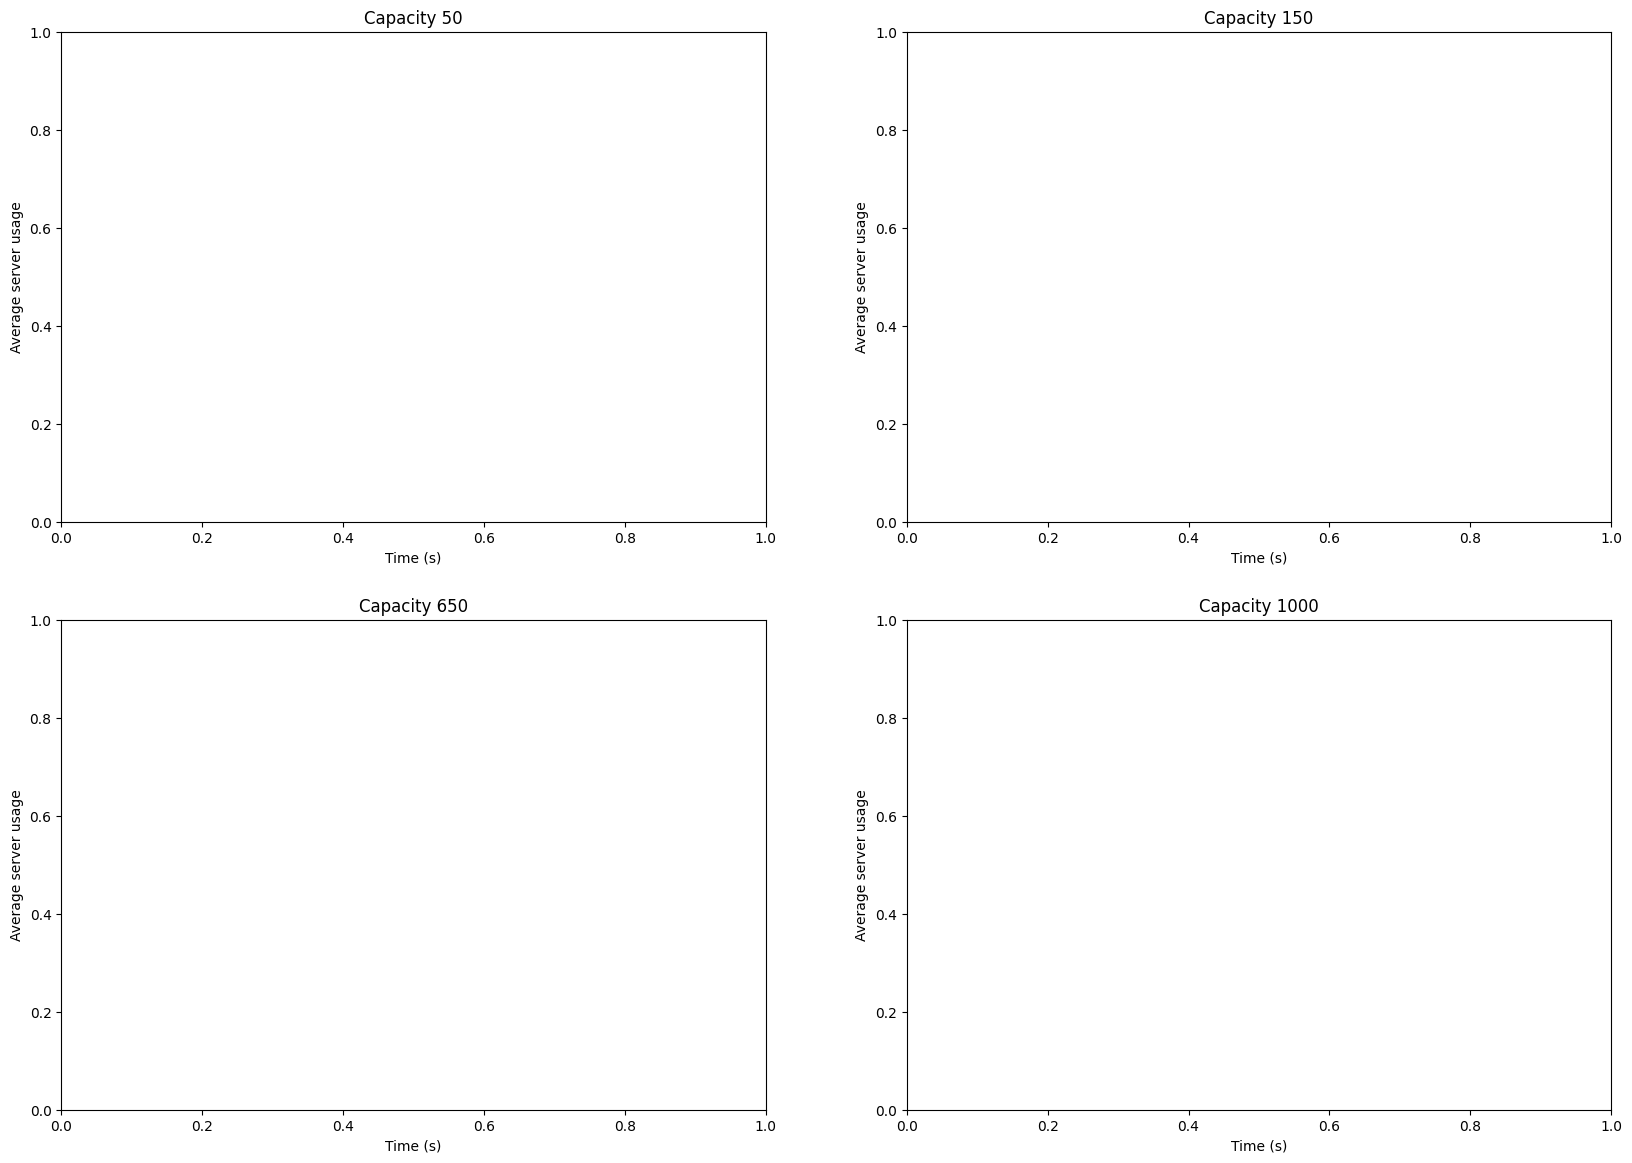

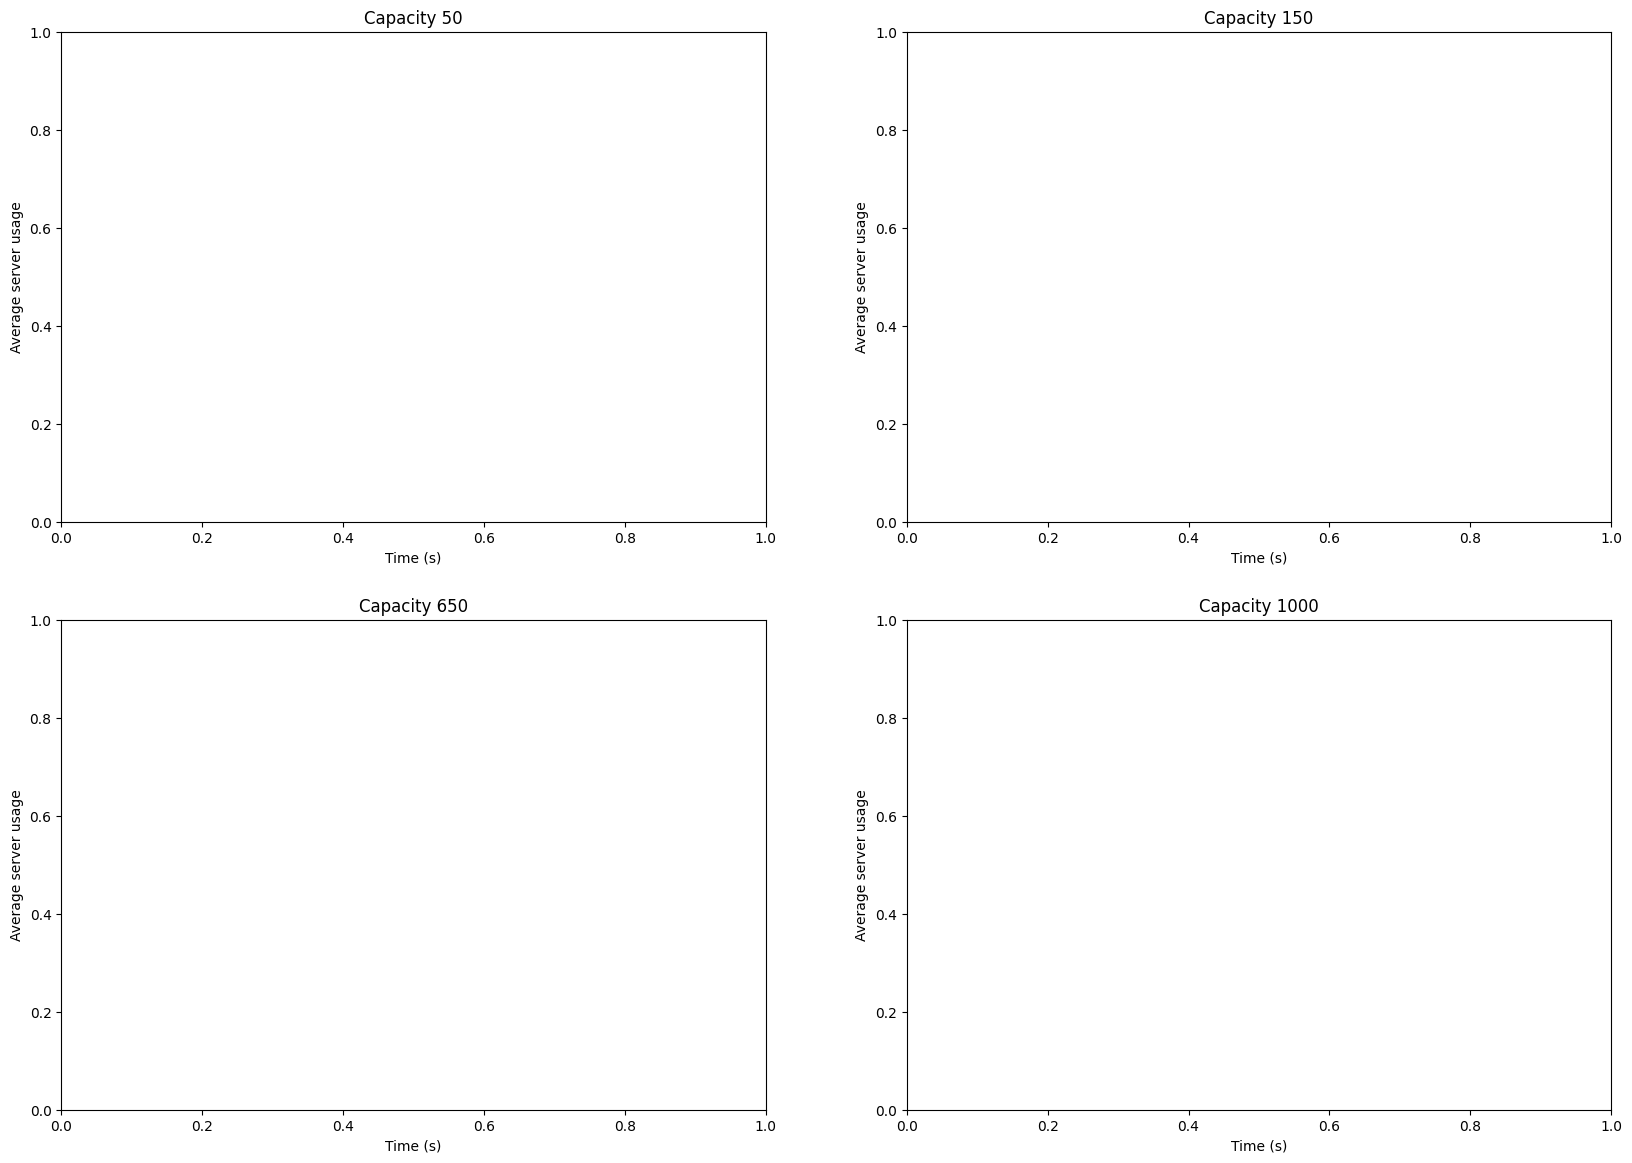

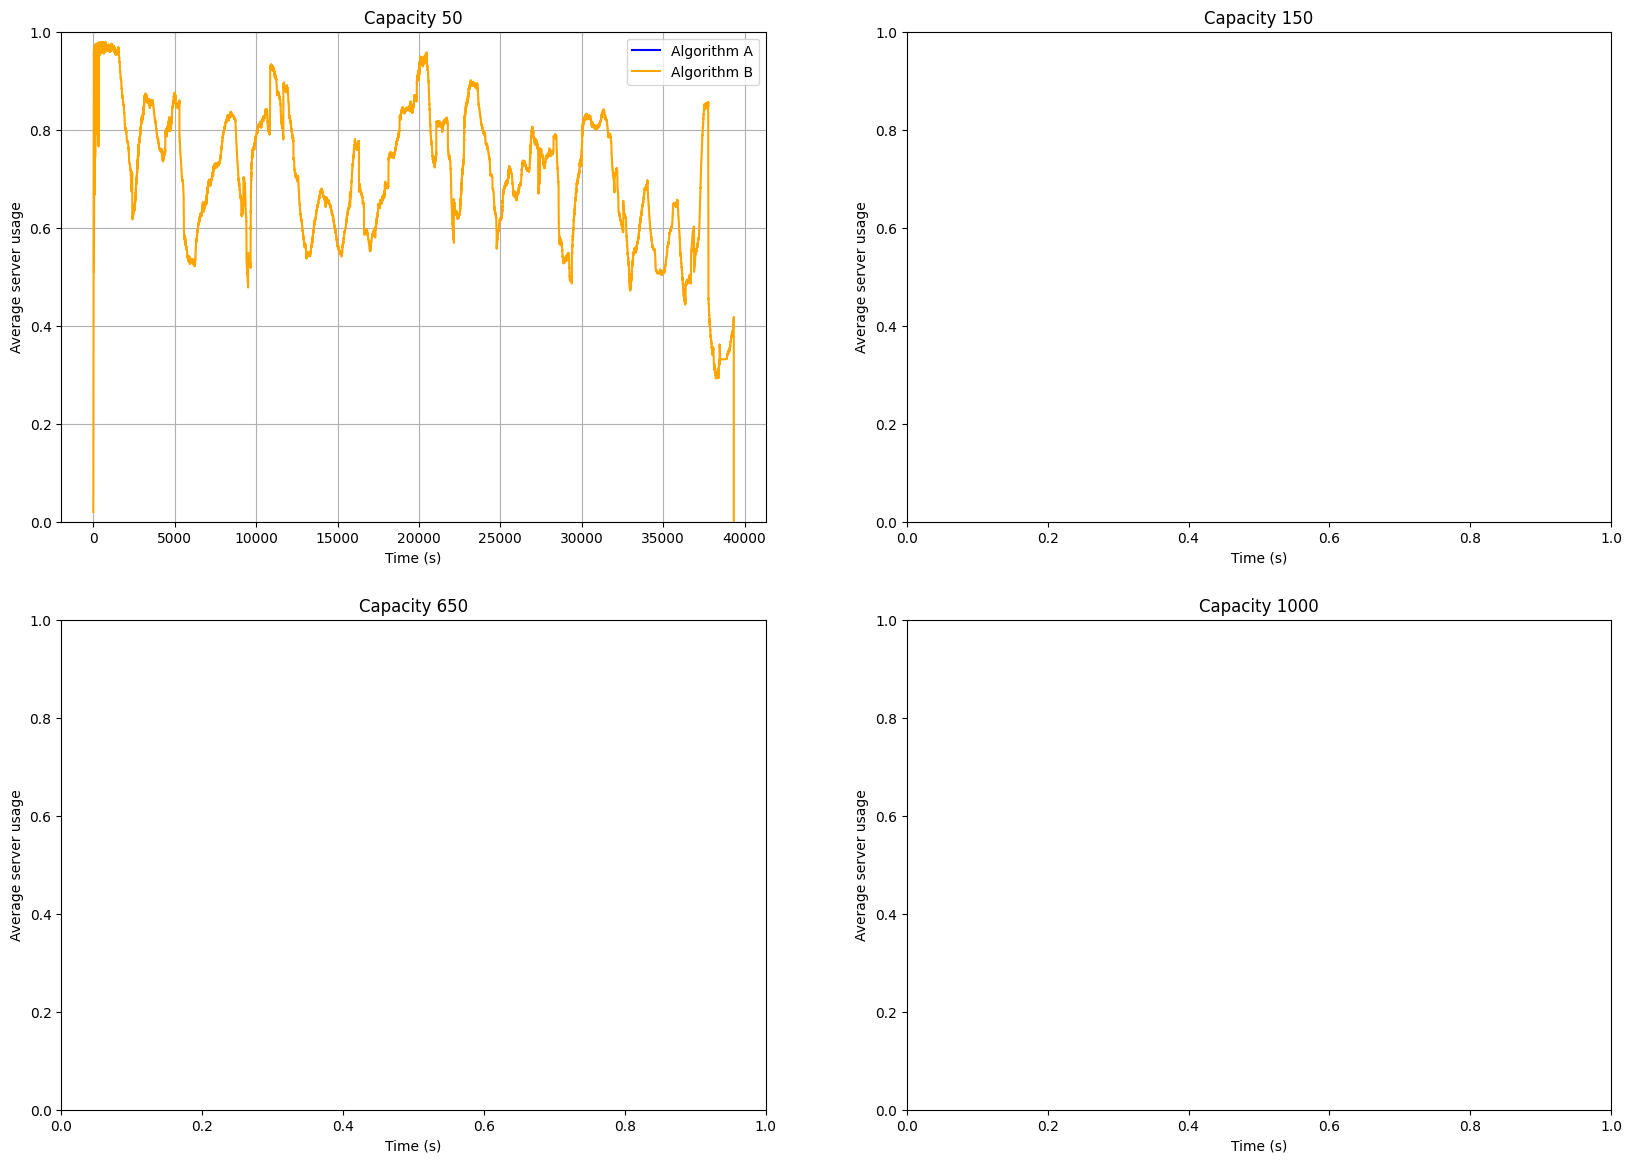

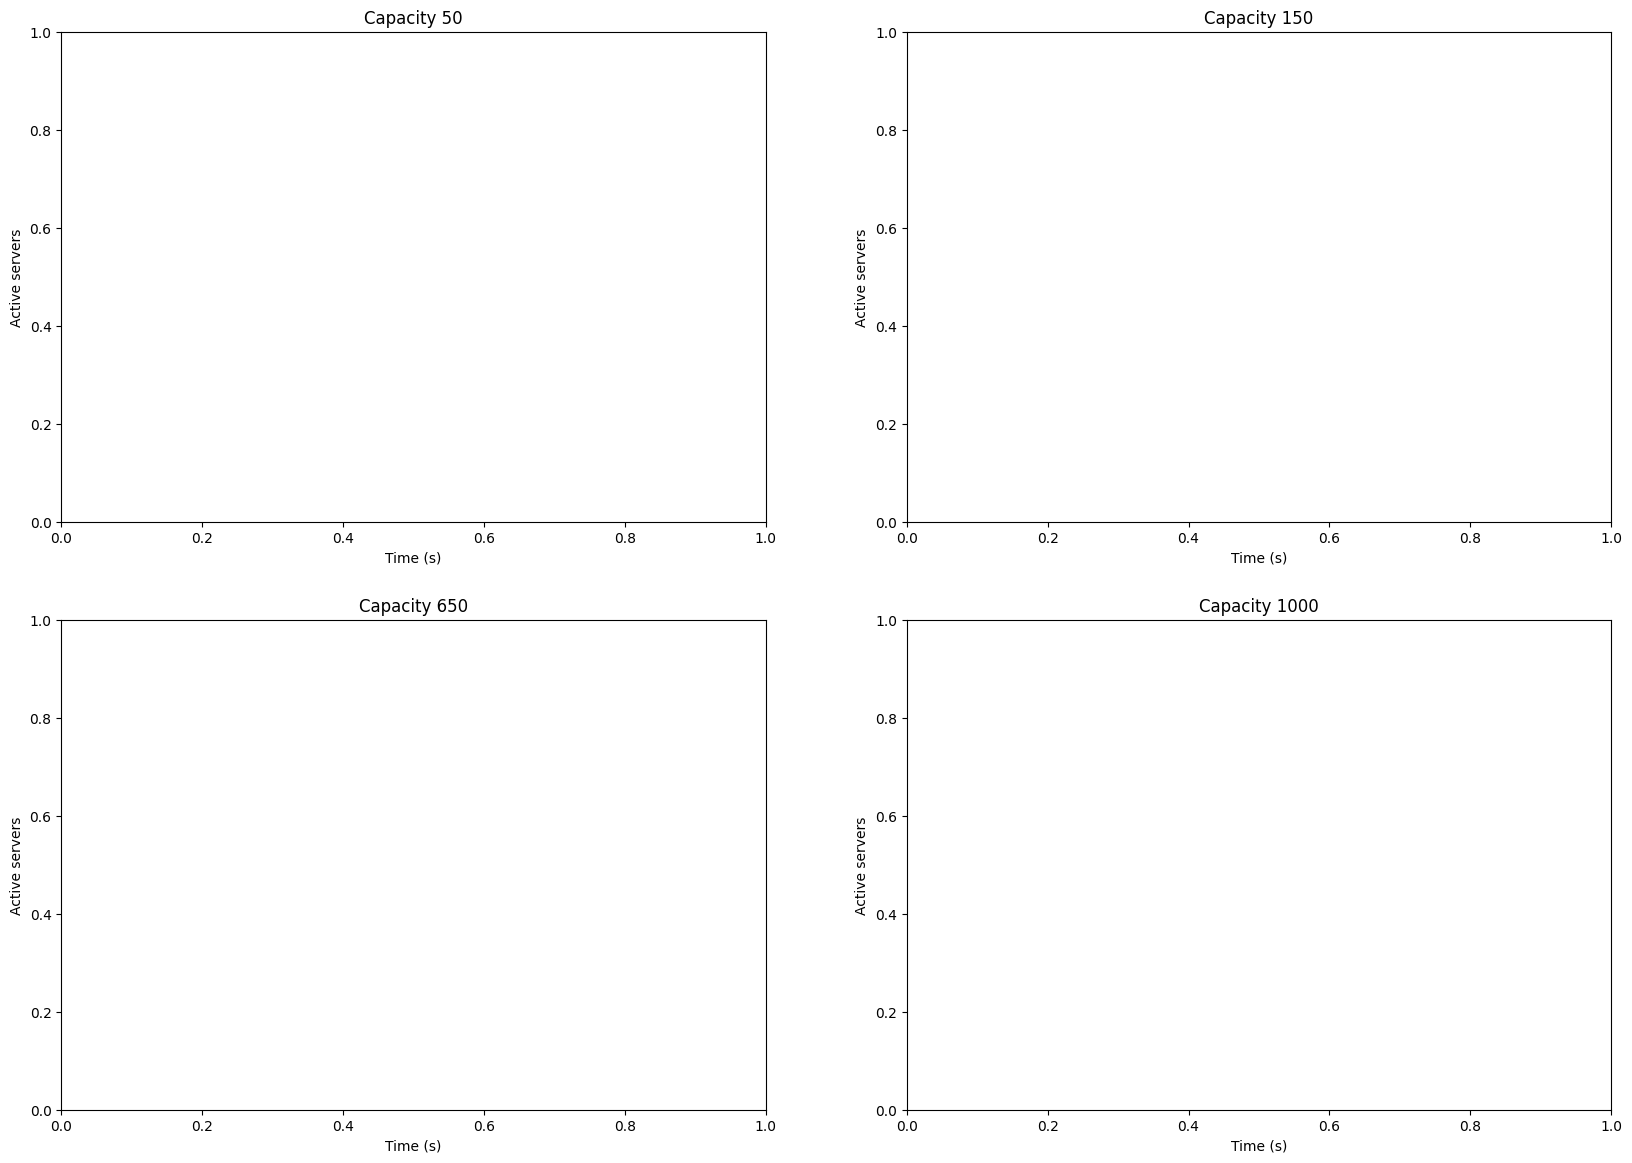

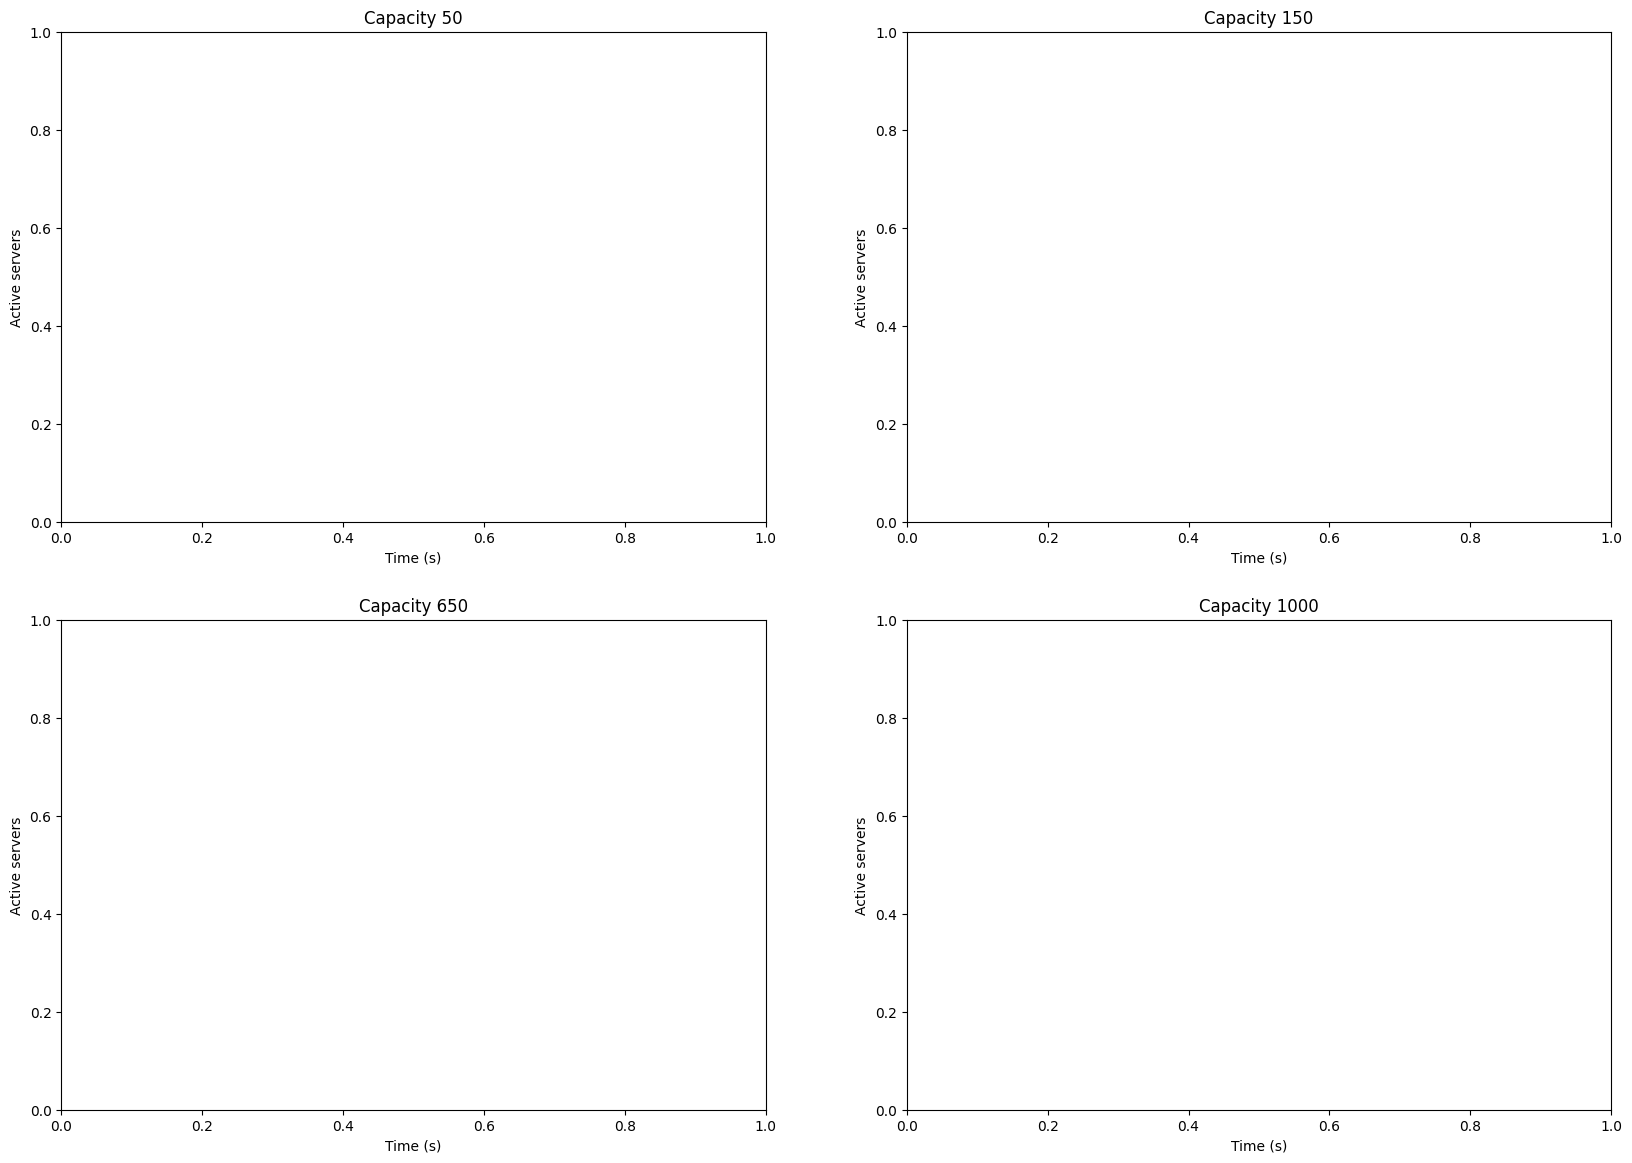

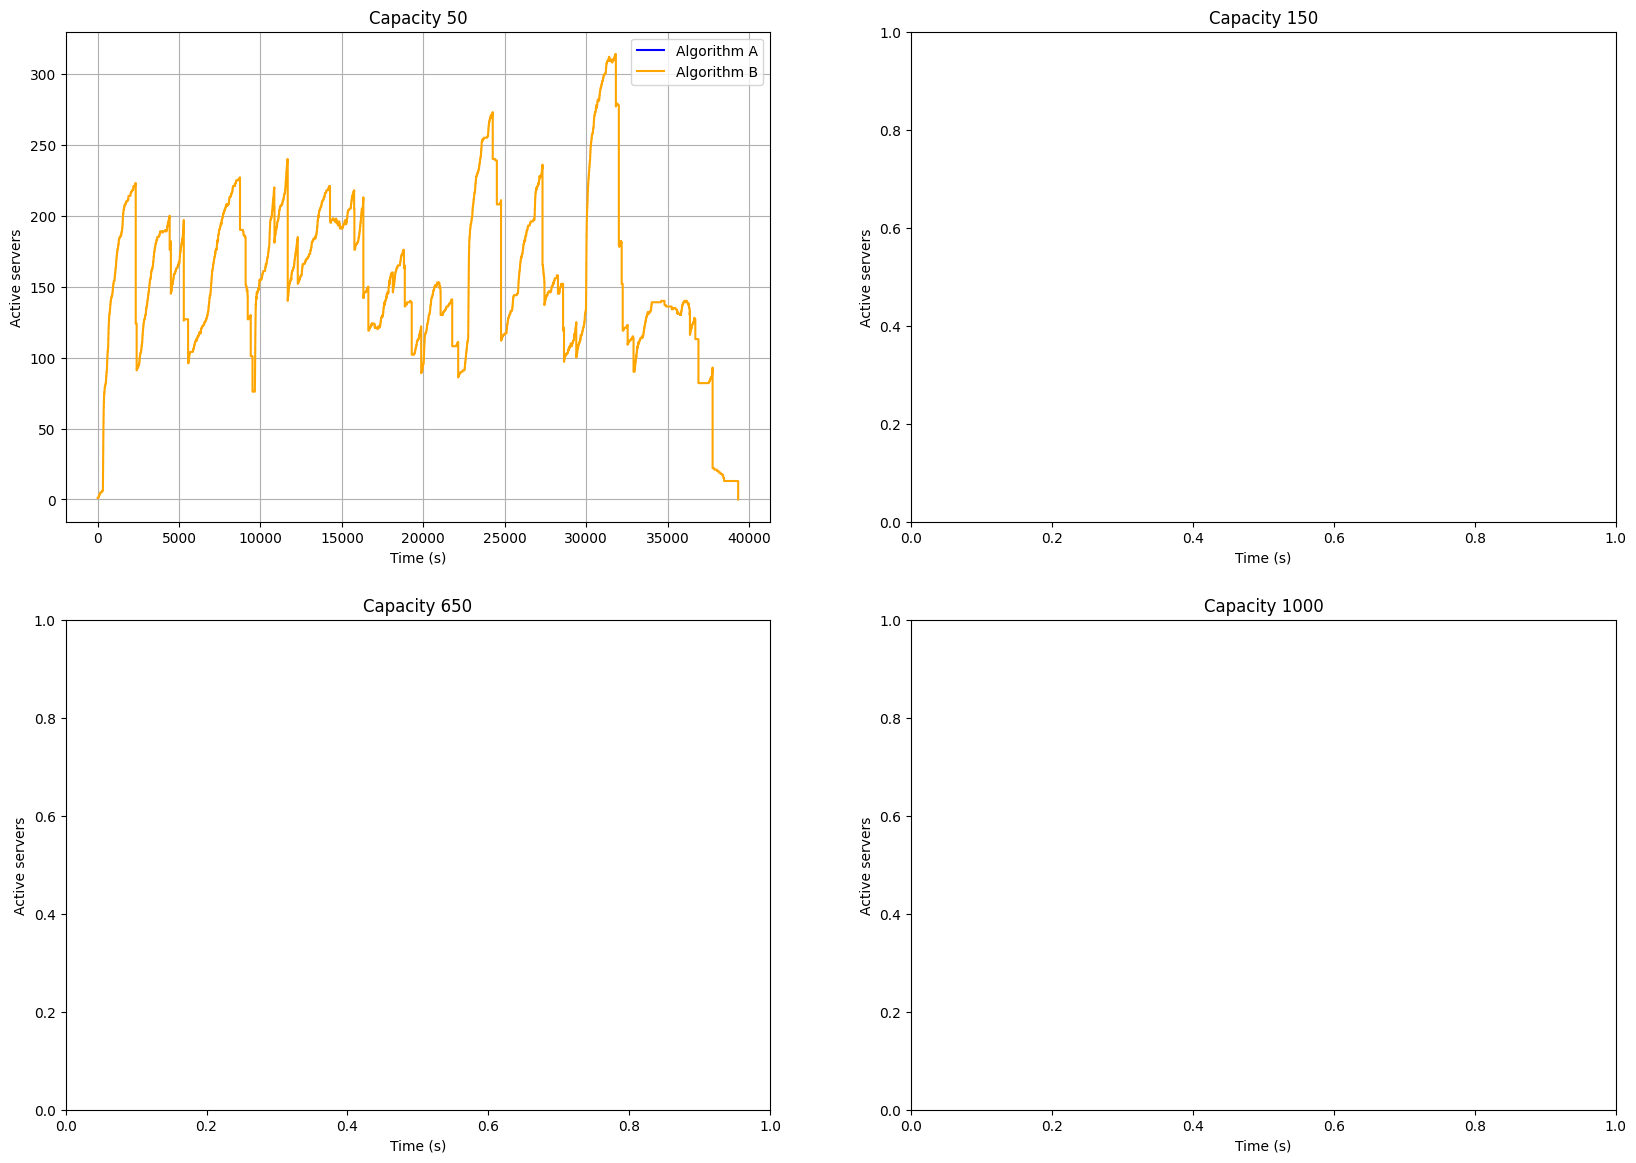

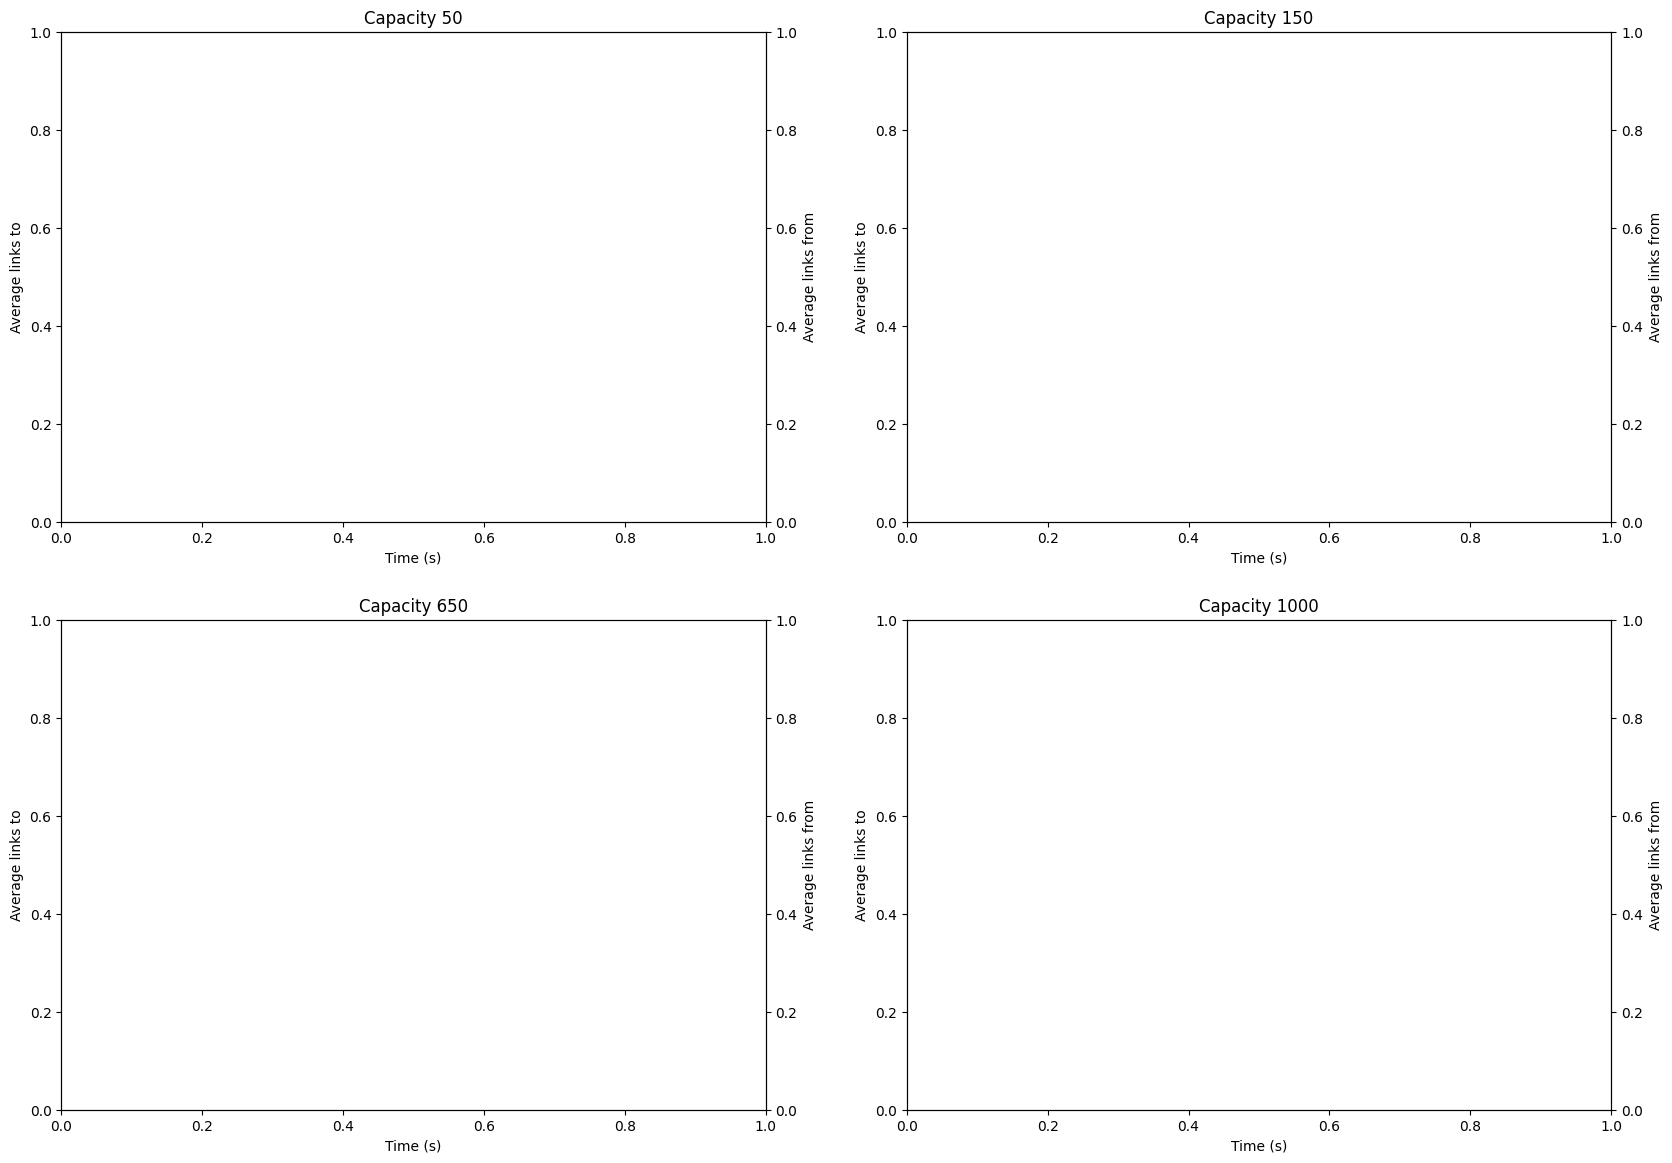

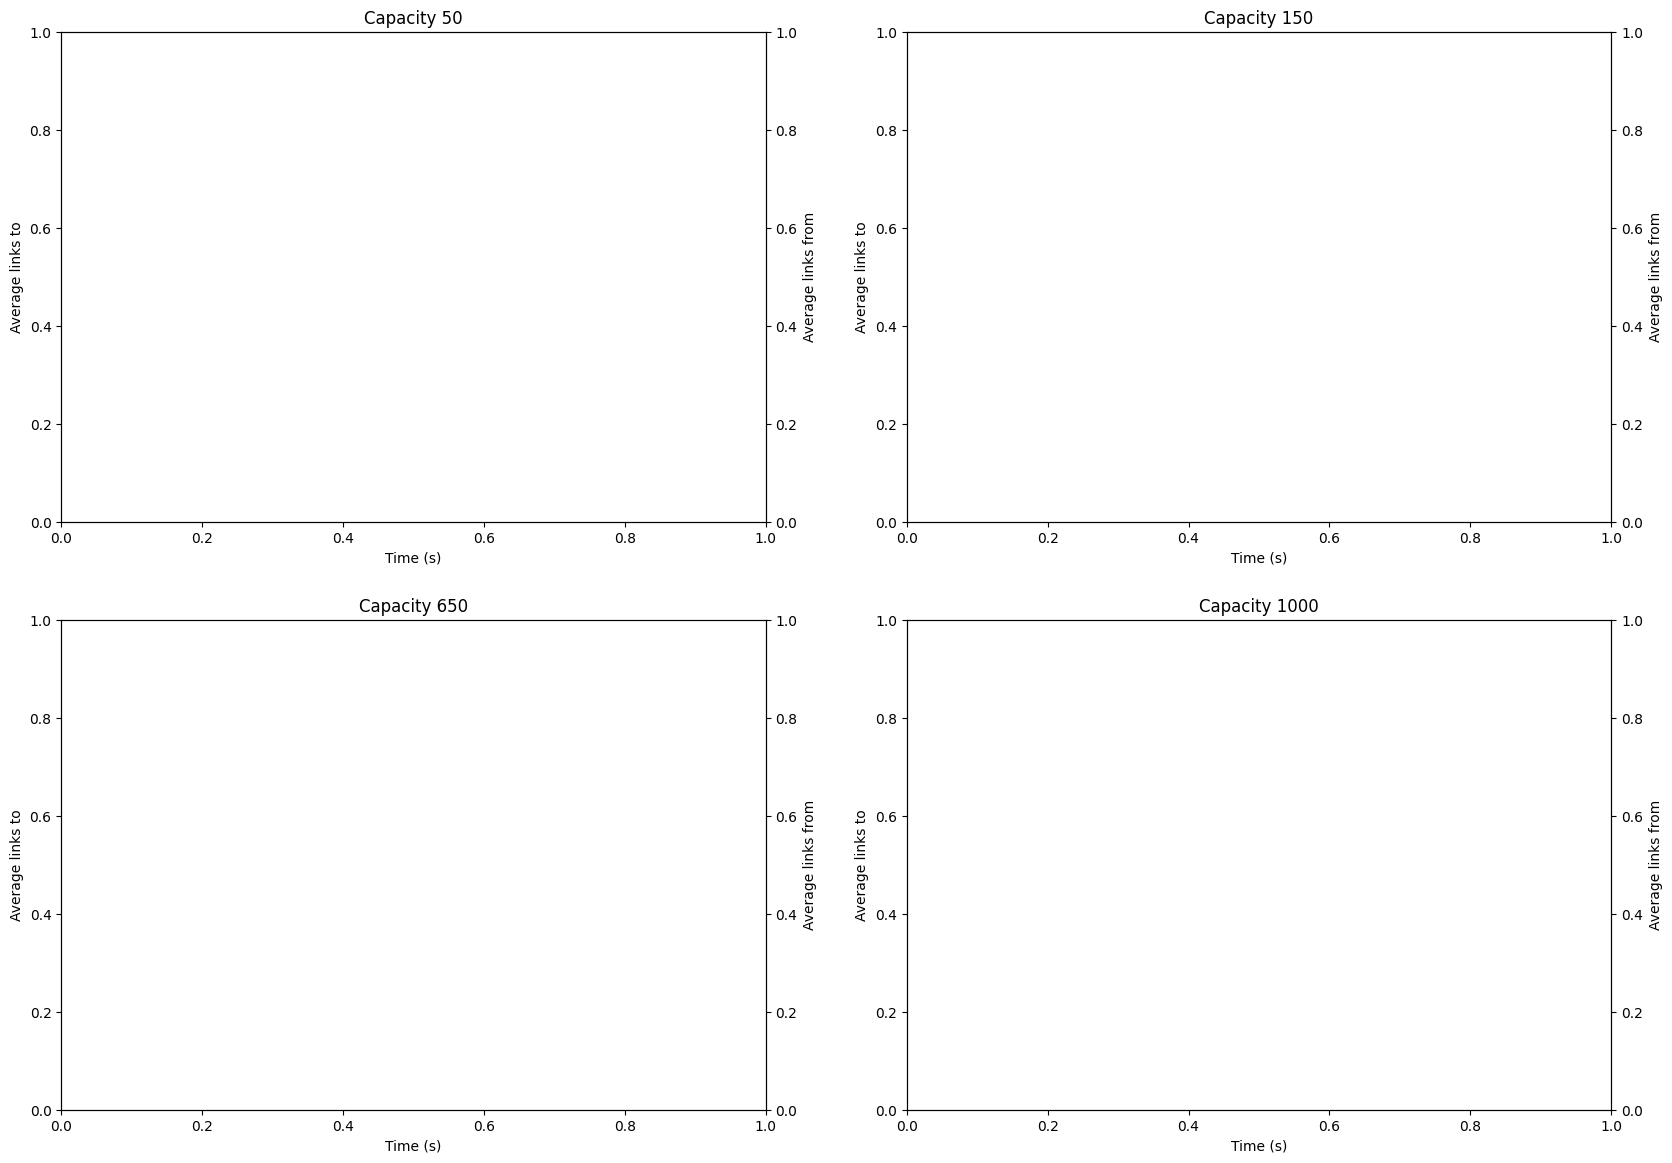

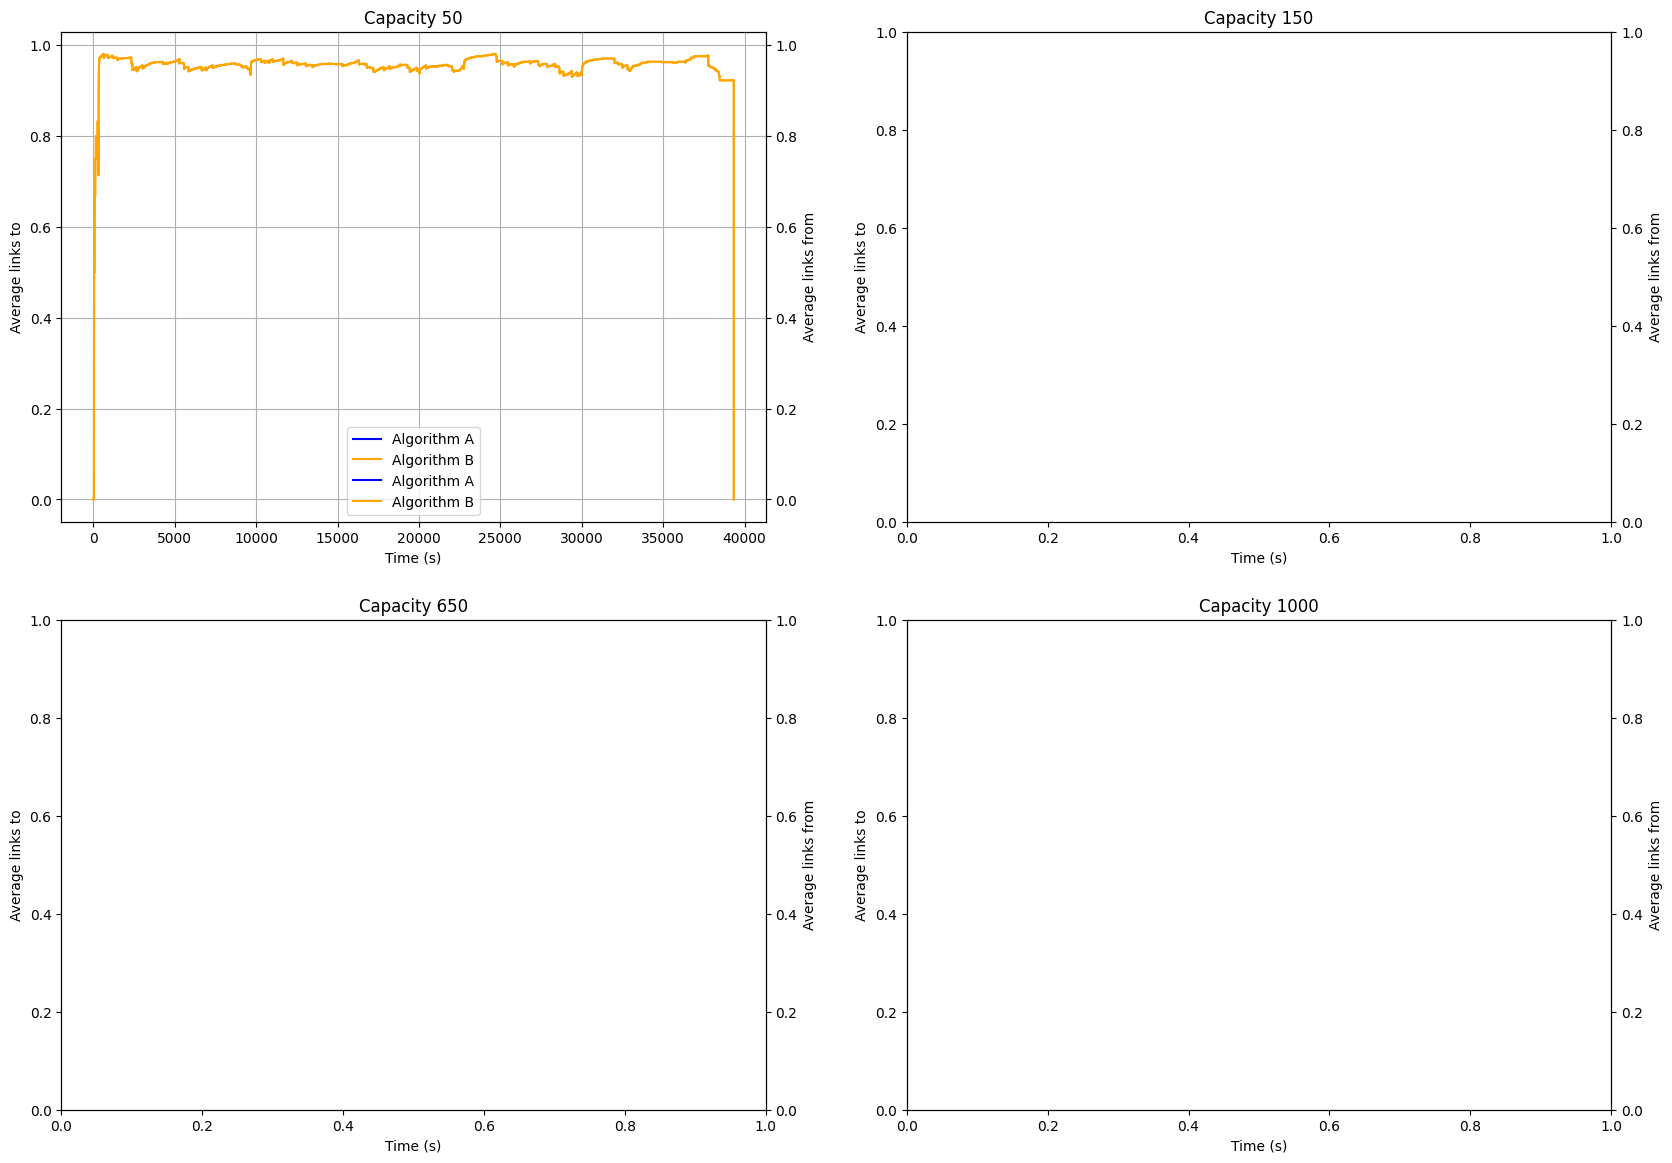

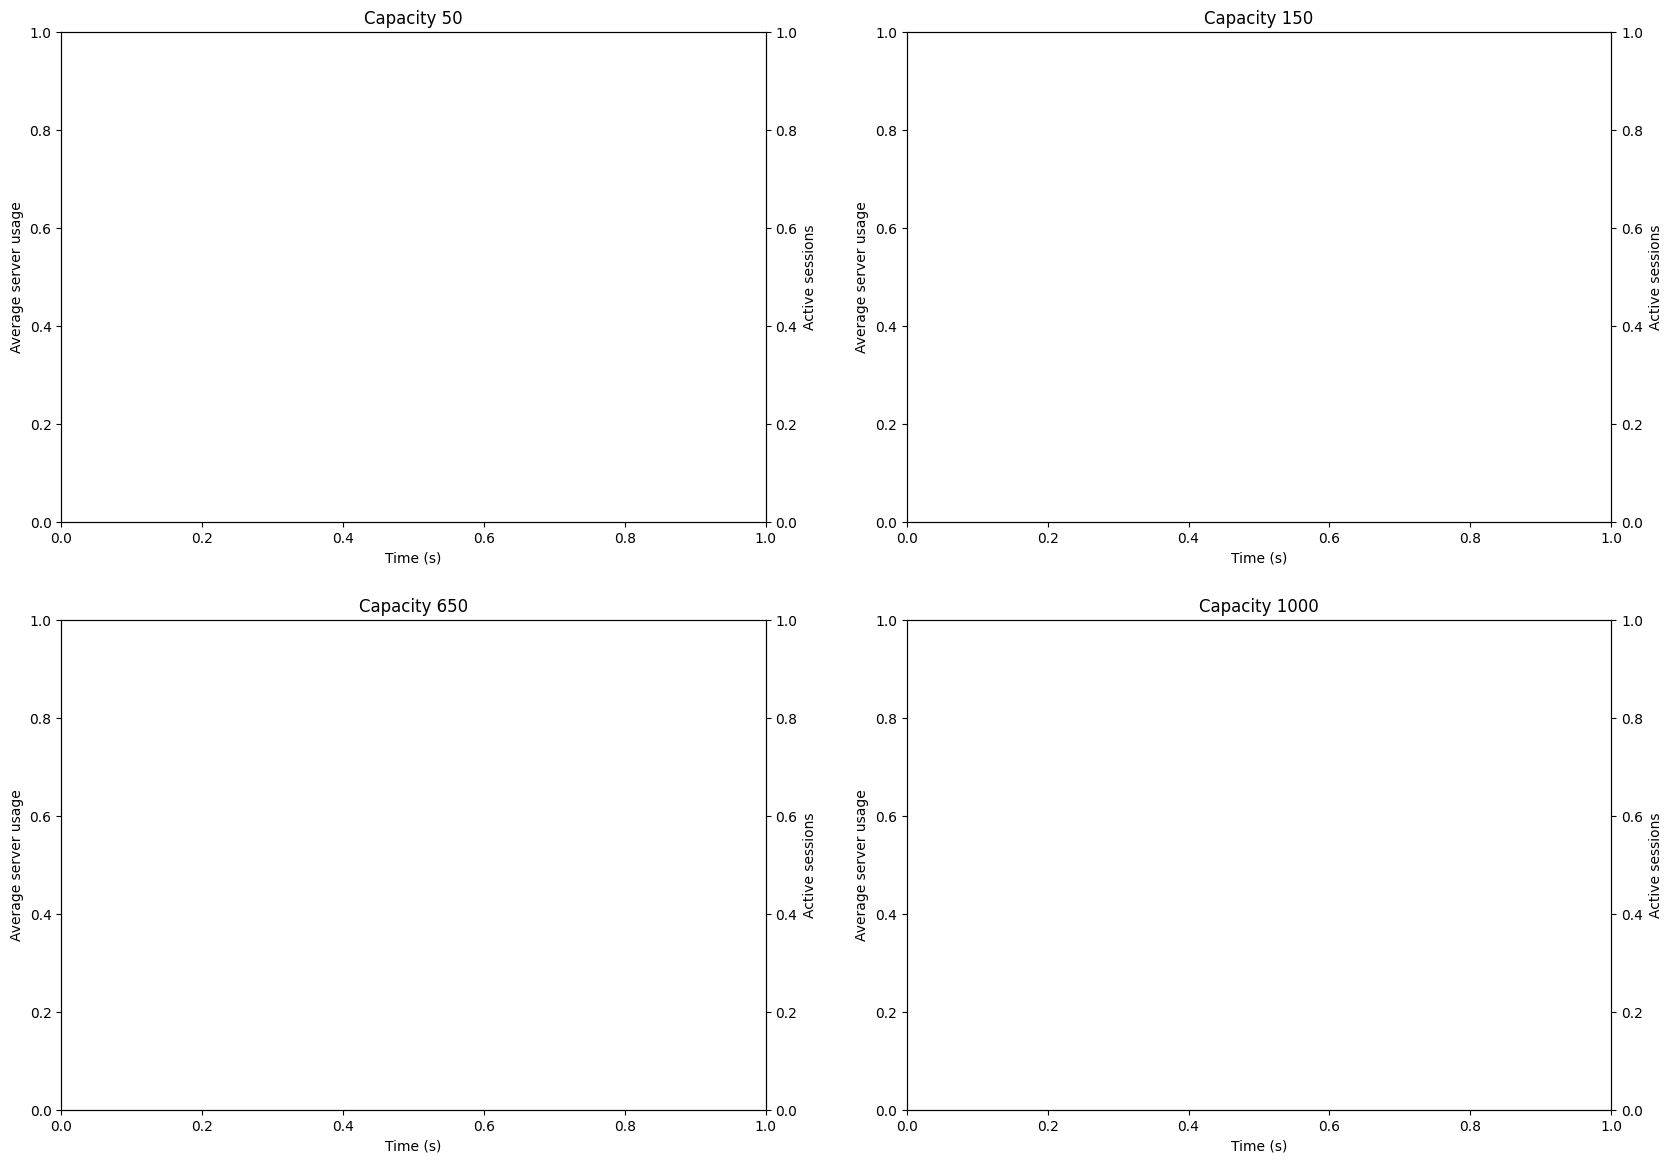

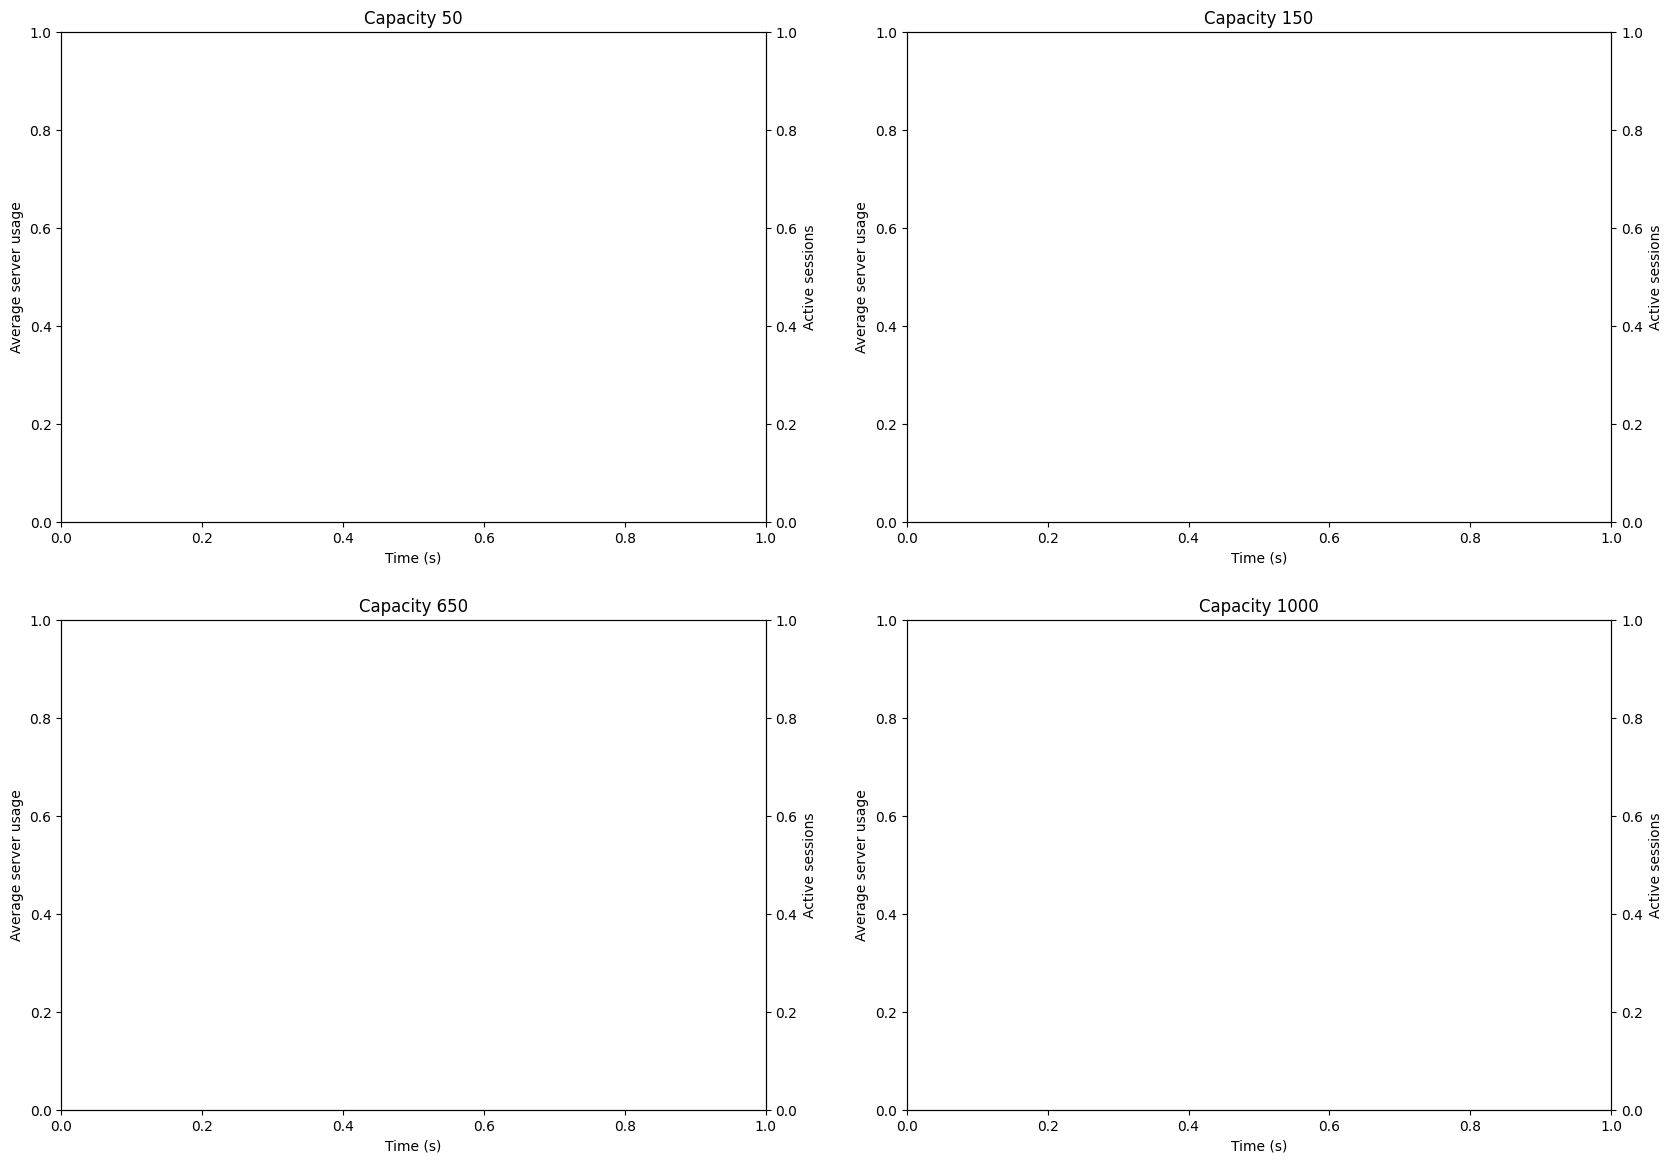

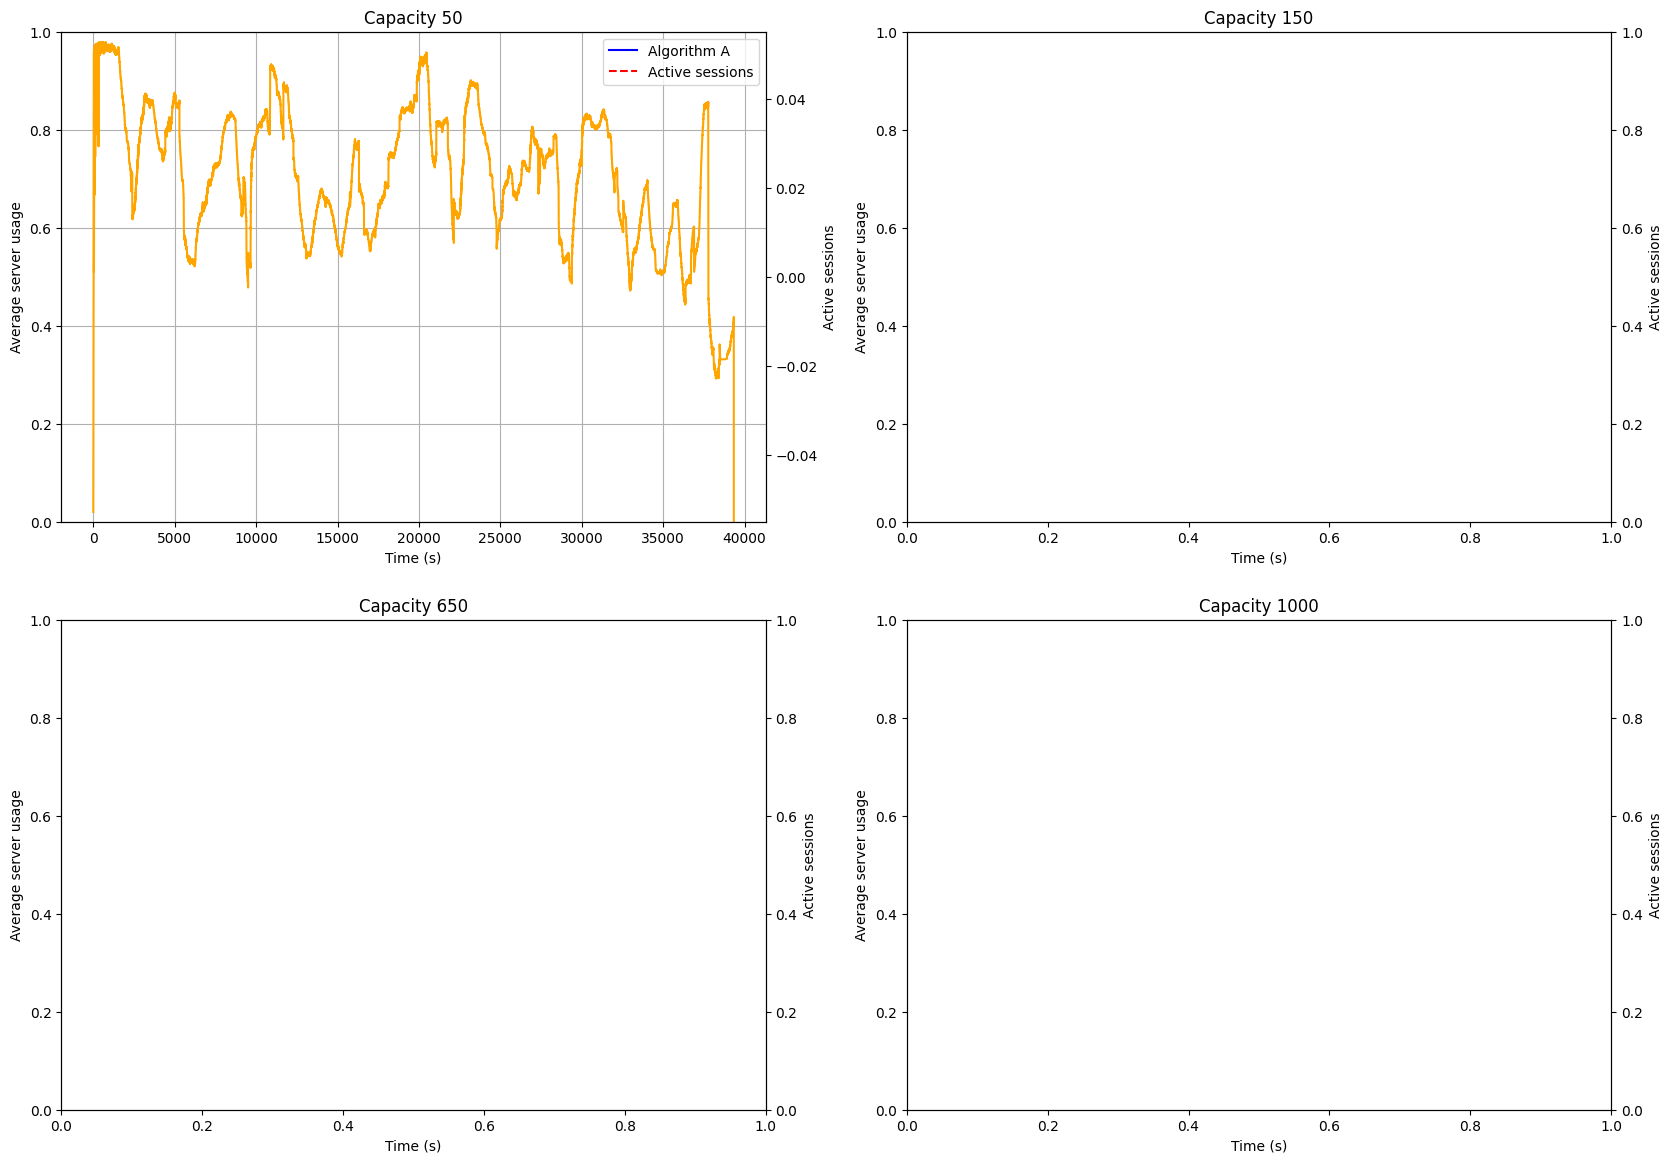

In [ ]:
def create_all_plots():
    """
    Create all plots by reading CSV files as needed.
    Always uses complete data (no sampling).
    """
    
    # Define what we want to plot
    plot_configs = [
        {"params": ["server_platform_time_cost"], "labels": ["Server time cost (s)"], "title": "Server Time Cost"},
        {"params": ["server_platform_avg_usage"], "labels": ["Average server usage"], "title": "Server Usage"},
        {"params": ["n_servers_current"], "labels": ["Active servers"], "title": "Active Servers"},
        {"params": ["avg_links_to", "avg_links_from"], "labels": ["Average links to", "Average links from"], "title": "Link Averages"},
        {"params": ["server_platform_avg_usage", "sessions"], "labels": ["Average server usage", "Active sessions"], "title": "Usage & Sessions"}
    ]
    plot_figs = {}
    plot_axes = {}
    
    for config in plot_configs:
        parameters = config["params"]
        y_labels = config["labels"]
        plot_title = config["title"]
        
        for instance_type in instance_types:
            # Create subplot structure
            fig, axs = plt.subplots(2, 2, figsize=(20, 14))
            axs = axs.flatten()
            
            for i, capacity in enumerate(capacities):
                axs[i].set_title(f"Capacity {capacity}")
            plot_axes[plot_title] = [[axs[0]], [axs[1]], [axs[2]], [axs[3]]]
            for ax in plot_axes[plot_title]:
                axis = ax[0]
                axis.set_xlabel("Time (s)")
                axis.set_ylabel(y_labels[0])  # Set the label for the primary y-axis
                if len(y_labels) > 1:
                    for i in range(1, len(parameters)):
                        ax_new = axis.twinx()
                        ax_new.spines['right'].set_position(('outward', 30 * (i - 1)))
                        ax_new.set_ylabel(y_labels[i])  # Set the label for the secondary y-axes
                        ax.append(ax_new)
            plot_figs[plot_title] = fig
    
    sessions_data = {}
    for instance_type in instance_types:
        for c, server_capacity in enumerate(capacities):
            for algo in algorithms:
                filepath = file_registry[instance_type][server_capacity][algo]["filepath"]
                df = load_csv_data(filepath)
                if not instance_type in sessions_data:
                    sessions_data[instance_type] = calculate_session_progression(df)
                for config in plot_configs:
                    parameters = config["params"]
                    y_labels = config["labels"]
                    plot_title = config["title"]

                    axs = plot_axes[plot_title][c]
                    fig = plot_figs[plot_title]
                
                    # Plot each parameter
                    for p_idx, parameter in enumerate(parameters):
                        axis = axs[p_idx]
                        if parameter == "sessions":
                            sessions = sessions_data[instance_type]
                            axis.plot(df["timestamp"], sessions,
                                        label="Active sessions", color="red", linestyle='--')
                        else:
                            axis.plot(df["timestamp"], df[parameter], label=f"{algo}", color=alg_colors[algo.split()[-1]])

                        # Set reasonable limits for usage percentage
                        if parameter == "server_platform_avg_usage":
                            axis.set_ylim([0, 1])

                    # Combine legends from all axes
                    handles, labels = [], []
                    for a in axs:
                        h, l = a.get_legend_handles_labels()
                        handles.extend(h)
                        labels.extend(l)
                
                    if handles:
                        axs[0].legend(handles, labels, loc='best')
                    axs[0].grid(True)
            del df
            break
        del sessions_data[instance_type]
        sessions_data.clear()

# Create all plots using complete data
# TODO: fix errors
create_all_plots()

'  Processing small instances...'

'    Reading Algorithm A data for capacity 50...'

'    Reading Algorithm B data for capacity 50...'

'    Reading Algorithm C data for capacity 50...'

'    Reading Algorithm A data for capacity 150...'

...

'    Reading Algorithm C data for capacity 1000...'

'  Processing medium instances...'

'    Reading Algorithm A data for capacity 50...'

'    Reading Algorithm B data for capacity 50...'

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

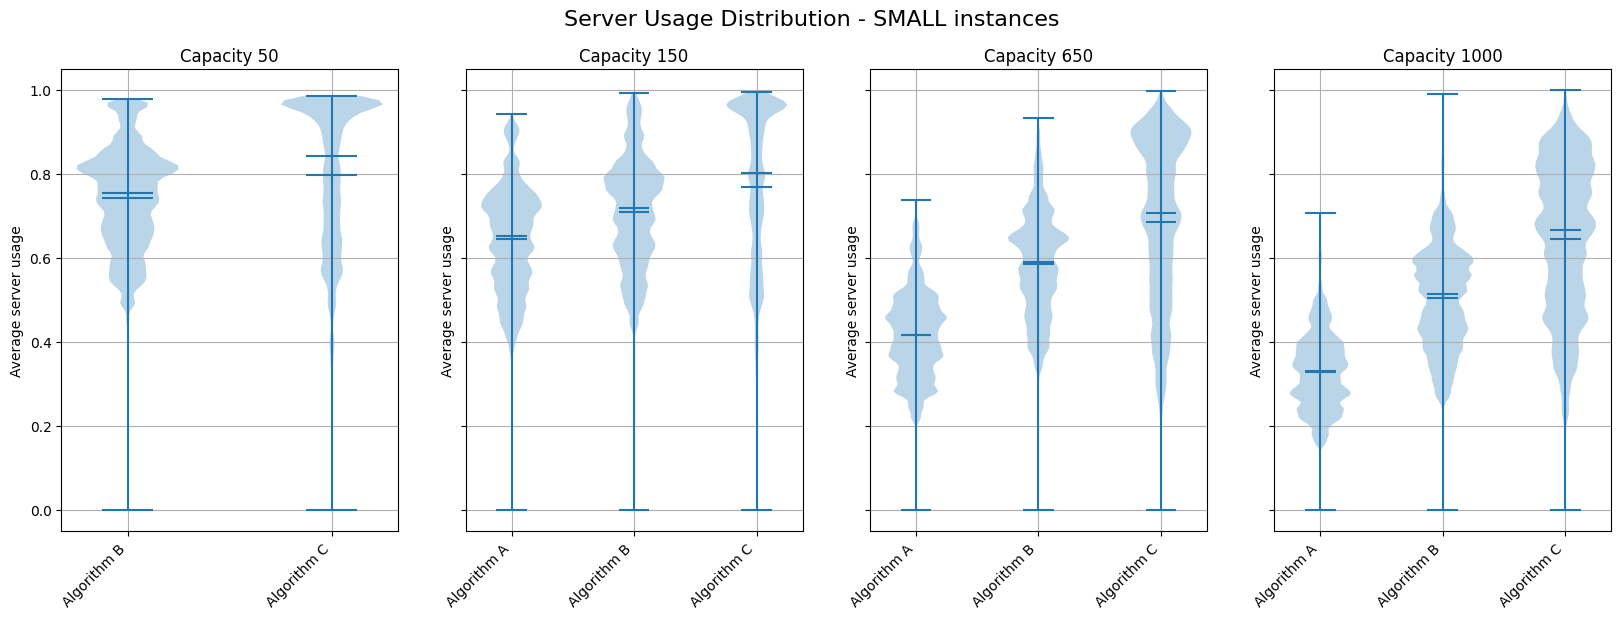

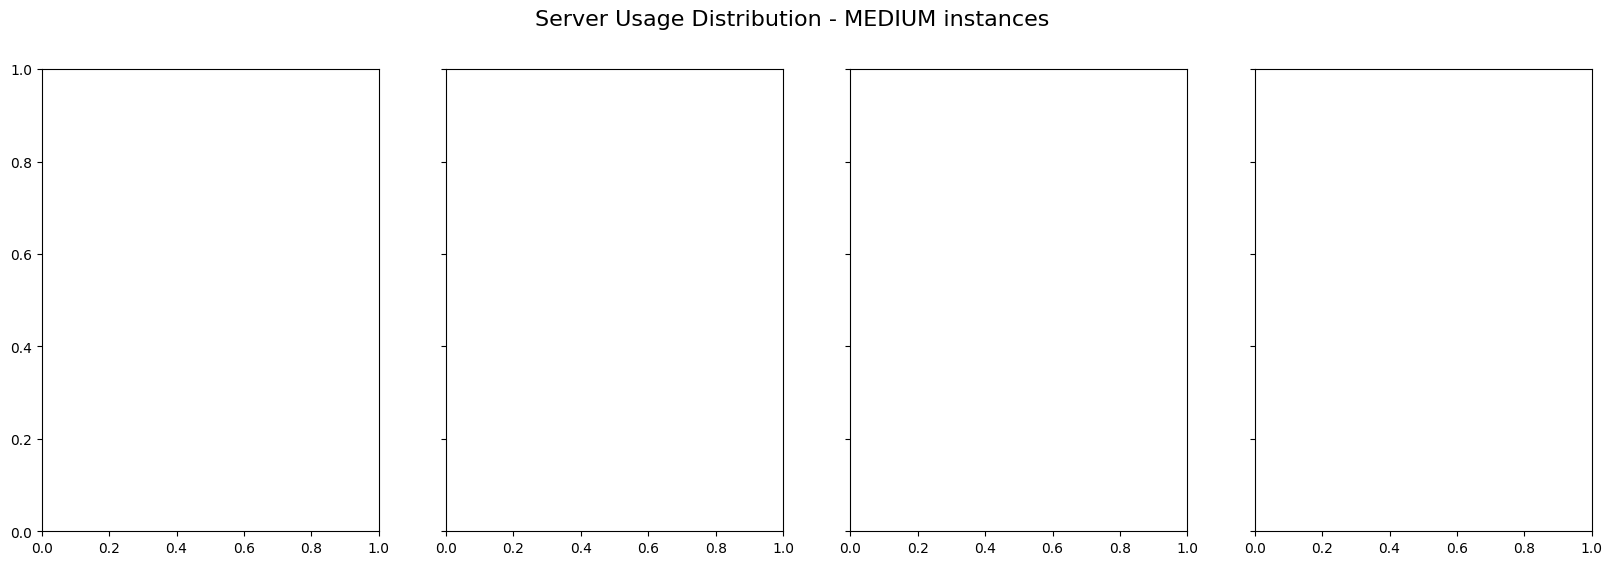

In [ ]:
for instance_type in instance_types:
    
    fig, axs = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
    fig.suptitle(f"Server Usage Distribution - {instance_type.upper()} instances", fontsize=16)
    
    for idx, capacity in enumerate(capacities):
        ax = axs[idx]
        data = []
        labels = []
        
        for algo_name in file_registry[instance_type][capacity]:
            file_info = file_registry[instance_type][capacity][algo_name]
            filepath = file_info["filepath"]
            
            # Load complete data and extract server usage
            df = load_csv_data(filepath)
            
            if len(df) > 0 and "server_platform_avg_usage" in df.columns:
                usage_values = df["server_platform_avg_usage"].dropna().tolist()
                if len(usage_values) > 0:
                    data.append(usage_values)
                    labels.append(algo_name)
            
            del df  # Free memory immediately
        
        if len(data) > 0:
            ax.violinplot(data, showmeans=True, showmedians=True)
            ax.set_xticks(range(1, len(labels) + 1))
            ax.set_xticklabels(labels, rotation=45, ha='right')
            ax.set_title(f"Capacity {capacity}")
            ax.set_ylabel("Average server usage")
            ax.grid(True)

In [ ]:
# Calculate maximum active servers table
def calculate_max_active_servers():
    """Calculate max active servers by reading complete files"""
    
    rows = []
    
    for instance_type in instance_types:
        display(f"Processing {instance_type} instances for max servers...")
        
        for capacity in capacities:
            # Initialize algorithm maxima
            alg_max = {alg: None for alg in alg_colors.keys()}
            
            for algo_name in file_registry[instance_type][capacity]:
                file_info = file_registry[instance_type][capacity][algo_name]
                filepath = file_info["filepath"]
                
                display(f"  Reading {algo_name} data for capacity {capacity}...")
                
                # Load complete data and find maximum n_servers_current
                df = load_csv_data(filepath)
                
                if len(df) > 0 and "n_servers_current" in df.columns:
                    try:
                        max_val = int(df["n_servers_current"].max())
                    except (ValueError, TypeError):
                        max_val = 0
                else:
                    max_val = 0
                
                del df  # Free memory immediately
                
                # Extract algorithm letter
                alg_letter = algo_name.split(" ")[1] if " " in algo_name else None
                
                if alg_letter in alg_max:
                    if alg_max[alg_letter] is None or max_val > alg_max[alg_letter]:
                        alg_max[alg_letter] = max_val
            
            # Create row for this instance_type/capacity combination
            row = {
                "Instance type": instance_type,
                "Server capacity": capacity,
            }
            
            # Add columns for each algorithm
            for alg, max_val in alg_max.items():
                row[f"Max active servers {alg}"] = int(max_val) if max_val is not None else 0
            
            rows.append(row)
    
    return pd.DataFrame(rows)

def to_latex_table(df, filename):
    """Save DataFrame as LaTeX table"""
    with open(filename, "w") as f:
        f.write(
            df.to_latex(
                index=False,
                float_format="%.0f",  # No decimals for server counts
                column_format="l" + "c" * (len(df.columns) - 1),
                escape=False,
            )
        )

# Calculate and display results using complete data
display("Calculating maximum active servers...")
max_active_servers_df = calculate_max_active_servers()
display(max_active_servers_df)

# Save to LaTeX
to_latex_table(max_active_servers_df, "max_active_servers.tex")
display("Results saved to max_active_servers.tex")